# FIFA Player Value Predictor

**Author:** Neel Mendapara  
**Dataset:** EA Sports FC 24 Complete Player Dataset (Kaggle)  
**Goal of This Project:** Predict football player market values using player attributes

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Data

In [2]:
df = pd.read_csv('../data/players.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Total players: {df.shape[0]}')
print(f'Total features: {df.shape[1]}')
df.head()

Dataset shape: (180021, 109)
Total players: 180021
Total features: 109


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3


## 3. Select Relevant Columns

In [3]:
cols_to_keep = [
    'short_name', 'age', 'height_cm', 'weight_kg', 'nationality_name',
    'club_name', 'league_name', 'overall', 'potential', 'value_eur',
    'wage_eur', 'player_positions', 'preferred_foot', 'weak_foot',
    'skill_moves', 'international_reputation', 'pace', 'shooting',
    'passing', 'dribbling', 'defending', 'physic'
]

df = df[cols_to_keep]
df.head()

,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,...,preferred_foot,weak_foot,skill_moves,international_reputation,pace,shooting,passing,dribbling,defending,physic
0,K. Mbappé,24,182,75,France,Paris Saint Germain,Ligue 1,91,94,181500000.0,...,Right,4,5,5,97.0,90.0,80.0,92.0,36.0,78.0
1,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,185000000.0,...,Left,3,3,5,89.0,93.0,66.0,80.0,45.0,88.0
2,K. De Bruyne,32,181,75,Belgium,Manchester City,Premier League,91,91,103000000.0,...,Right,5,4,5,72.0,88.0,94.0,87.0,65.0,78.0
3,L. Messi,36,169,67,Argentina,Inter Miami,Major League Soccer,90,90,41000000.0,...,Left,4,4,5,80.0,87.0,90.0,94.0,33.0,64.0
4,K. Benzema,35,185,81,France,Al Ittihad,Pro League,90,90,51000000.0,...,Right,4,4,5,79.0,88.0,83.0,87.0,39.0,78.0


## 4. Check Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Missing %
physic               20024      11.12
defending            20024      11.12
dribbling            20024      11.12
passing              20024      11.12
shooting             20024      11.12
pace                 20024      11.12
value_eur             2153       1.20
club_name             1865       1.04
league_name           1865       1.04
wage_eur              1848       1.03


## 5. Clean the Data

In [5]:
# Drop rows where our target (value_eur) is missing
df = df.dropna(subset=['value_eur'])

# Remove players with 0 value (free agents/unrated)
df = df[df['value_eur'] > 0]

# Fill missing skill columns with median (for goalkeepers mostly)
skill_cols = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
for col in skill_cols:
    df[col] = df[col].fillna(df[col].median())

# Take the first position only (some players list multiple)
df['main_position'] = df['player_positions'].str.split(',').str[0].str.strip()

print(f'Cleaned dataset shape: {df.shape}')
df.head()

Cleaned dataset shape: (177868, 23)


,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,...,weak_foot,skill_moves,international_reputation,pace,shooting,passing,dribbling,defending,physic,main_position
0,K. Mbappé,24,182,75,France,Paris Saint Germain,Ligue 1,91,94,181500000.0,...,4,5,5,97.0,90.0,80.0,92.0,36.0,78.0,ST
1,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,185000000.0,...,3,3,5,89.0,93.0,66.0,80.0,45.0,88.0,ST
2,K. De Bruyne,32,181,75,Belgium,Manchester City,Premier League,91,91,103000000.0,...,5,4,5,72.0,88.0,94.0,87.0,65.0,78.0,CM
3,L. Messi,36,169,67,Argentina,Inter Miami,Major League Soccer,90,90,41000000.0,...,4,4,5,80.0,87.0,90.0,94.0,33.0,64.0,CF
4,K. Benzema,35,185,81,France,Al Ittihad,Pro League,90,90,51000000.0,...,4,4,5,79.0,88.0,83.0,87.0,39.0,78.0,CF


## 6. EDA: Top 10 Most Valuable Players

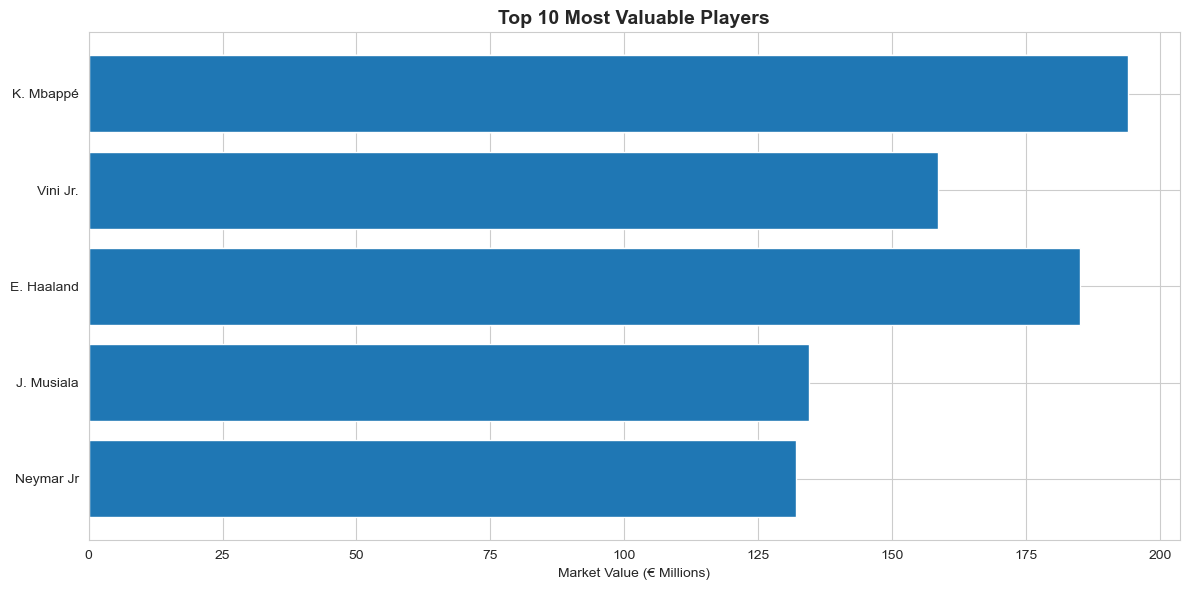

,short_name,value_eur,overall,club_name
36885,K. Mbappé,194000000.0,91,Paris Saint Germain
18350,K. Mbappé,190500000.0,91,Paris Saint Germain
56128,K. Mbappé,185500000.0,90,Paris Saint Germain
1,E. Haaland,185000000.0,91,Manchester City
0,K. Mbappé,181500000.0,91,Paris Saint Germain
8,Vini Jr.,158500000.0,89,Real Madrid
18370,E. Haaland,148000000.0,88,Manchester City
36905,E. Haaland,137500000.0,88,Borussia Dortmund
35,J. Musiala,134500000.0,86,FC Bayern München
56126,Neymar Jr,132000000.0,91,Paris Saint Germain


In [6]:
top10 = df.nlargest(10, 'value_eur')[['short_name', 'value_eur', 'overall', 'club_name']]

plt.figure(figsize=(12, 6))
plt.barh(top10['short_name'][::-1], top10['value_eur'][::-1] / 1_000_000, color='#1f77b4')
plt.xlabel('Market Value (€ Millions)')
plt.title('Top 10 Most Valuable Players', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/top10_valuable.png', dpi=150, bbox_inches='tight')
plt.show()
top10

## 7. EDA: Age Distribution

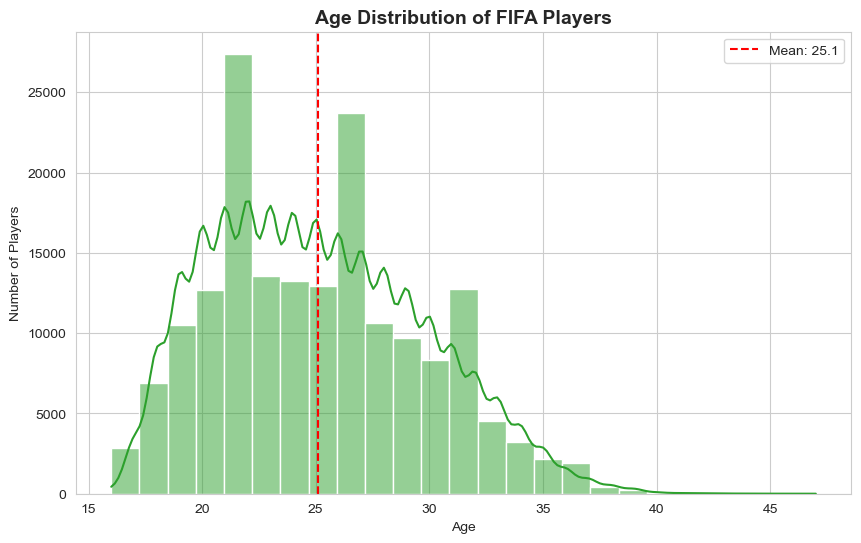

Average age: 25.1
Youngest: 16 | Oldest: 47


In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=25, kde=True, color='#2ca02c')
plt.title('Age Distribution of FIFA Players', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.legend()
plt.savefig('../visuals/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average age: {df['age'].mean():.1f}")
print(f"Youngest: {df['age'].min()} | Oldest: {df['age'].max()}")

## 8. EDA: Overall Rating vs Market Value

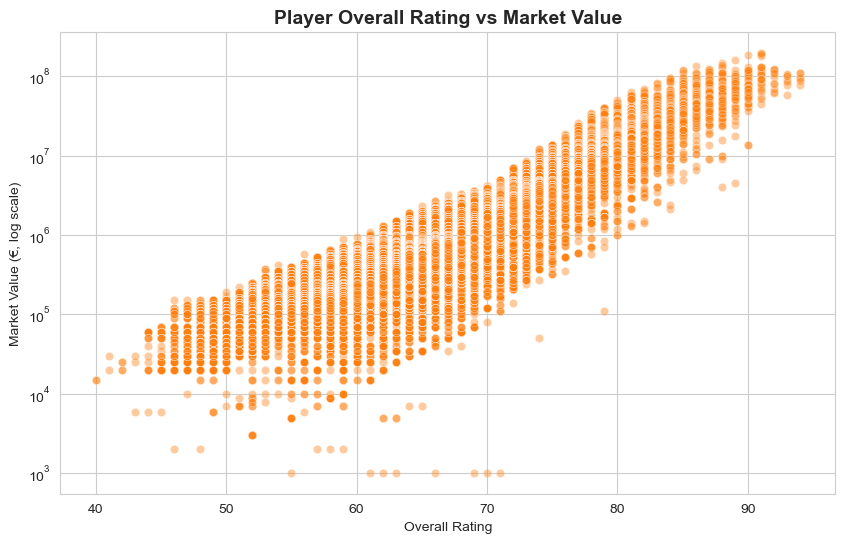

Correlation between Overall and Value: 0.563


In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='overall', y='value_eur', alpha=0.4, color='#ff7f0e')
plt.yscale('log')
plt.title('Player Overall Rating vs Market Value', fontsize=14, fontweight='bold')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value (€, log scale)')
plt.savefig('../visuals/rating_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

correlation = df['overall'].corr(df['value_eur'])
print(f'Correlation between Overall and Value: {correlation:.3f}')

## 9. EDA: Top 10 Leagues by Average Player Value

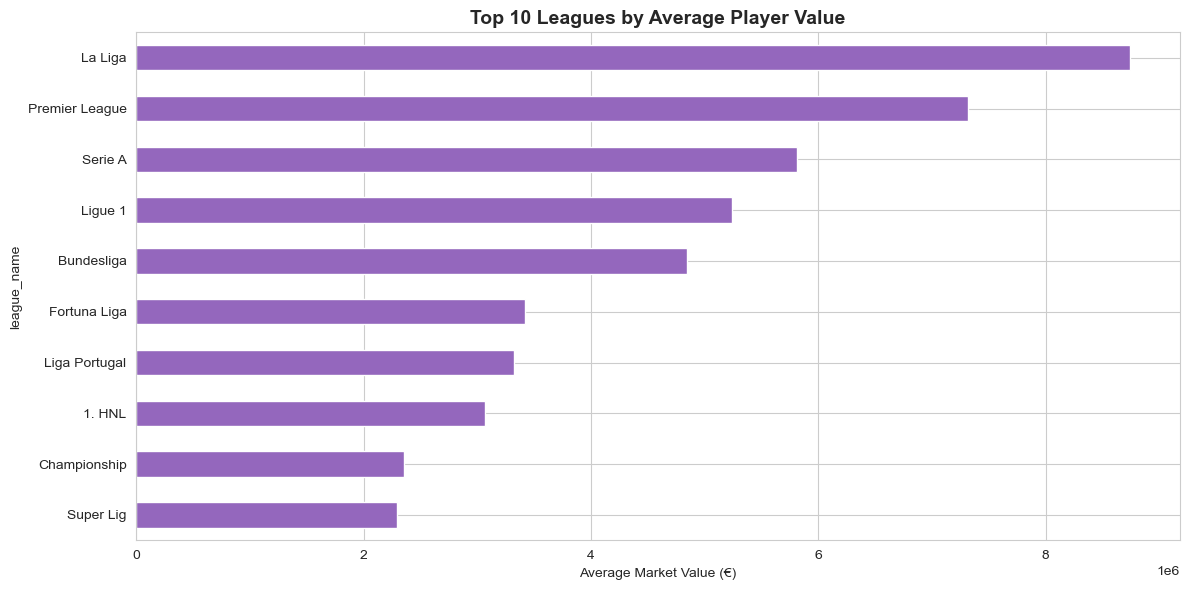

In [9]:
top_leagues = df.groupby('league_name')['value_eur'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_leagues.plot(kind='barh', color='#9467bd')
plt.gca().invert_yaxis()
plt.xlabel('Average Market Value (€)')
plt.title('Top 10 Leagues by Average Player Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/top_leagues.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Correlation Heatmap

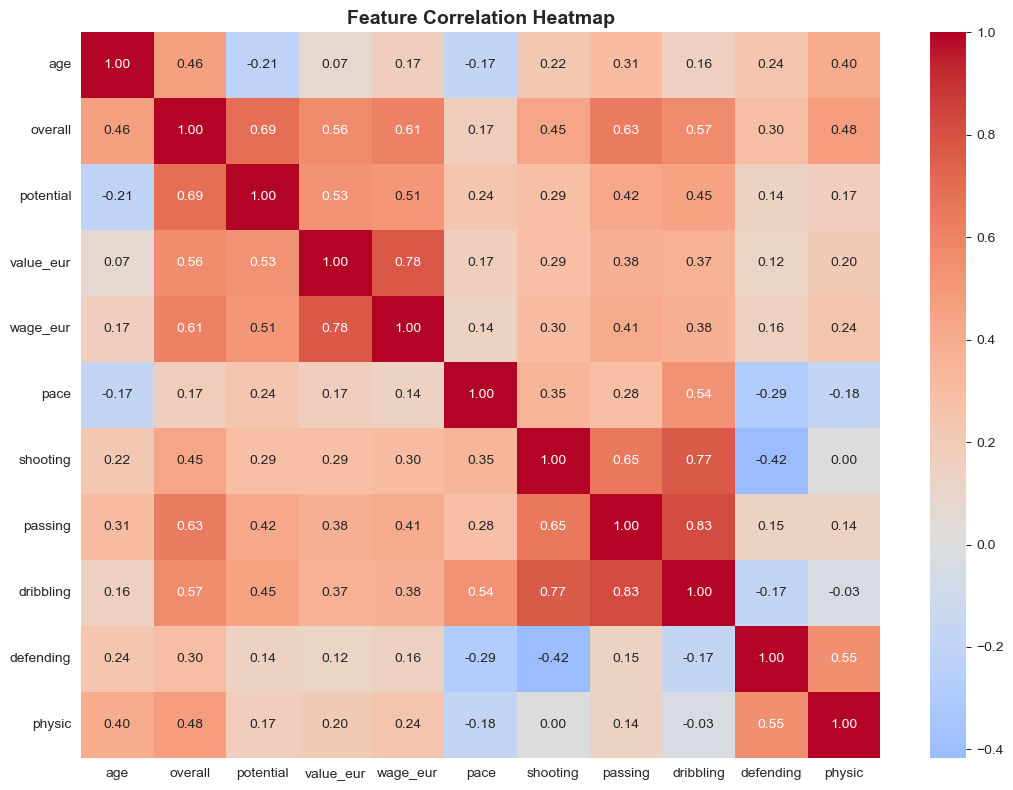

In [10]:
numeric_cols = ['age', 'overall', 'potential', 'value_eur', 'wage_eur',
                'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Prepare Features for Machine Learning

In [11]:
features = ['age', 'overall', 'potential', 'wage_eur', 'international_reputation',
            'weak_foot', 'skill_moves', 'pace', 'shooting', 'passing',
            'dribbling', 'defending', 'physic']

X = df[features]
y = df['value_eur']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (142294, 13)
Test set: (35574, 13)


## 12. Train Models

In [12]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Compare
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [r2_score(y_test, lr_preds), r2_score(y_test, rf_preds)],
    'MAE (€)': [mean_absolute_error(y_test, lr_preds), mean_absolute_error(y_test, rf_preds)]
})
print(results)

               Model  R² Score       MAE (€)
0  Linear Regression  0.626092  1.620855e+06
1      Random Forest  0.936685  4.522431e+05


## 13. Feature Importance

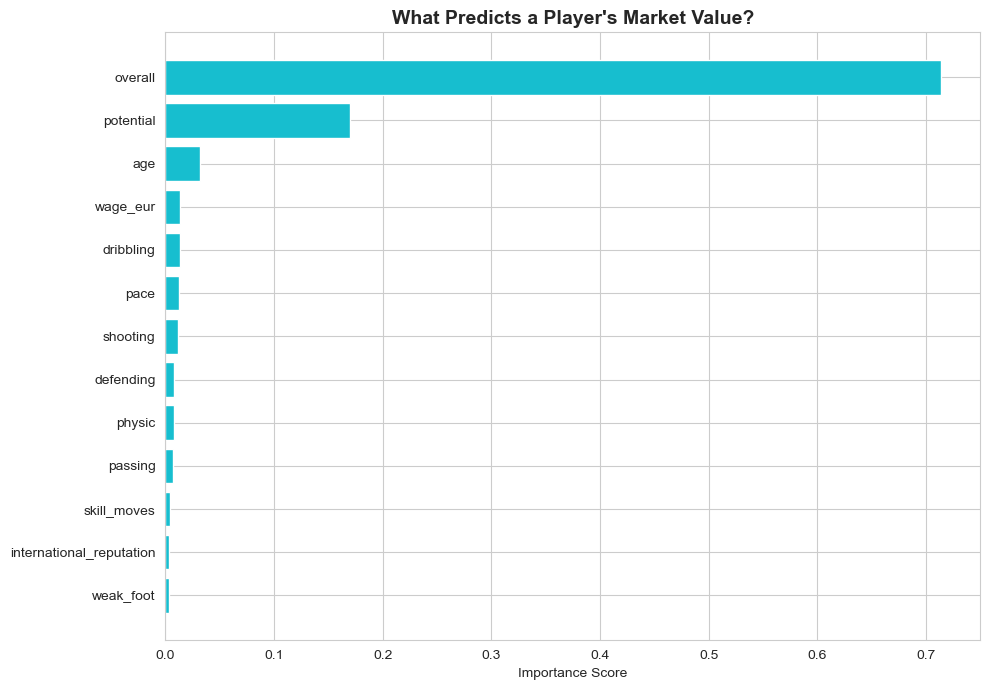

In [13]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance['Feature'], importance['Importance'], color='#17becf')
plt.xlabel('Importance Score')
plt.title("What Predicts a Player's Market Value?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Predictions vs Actual

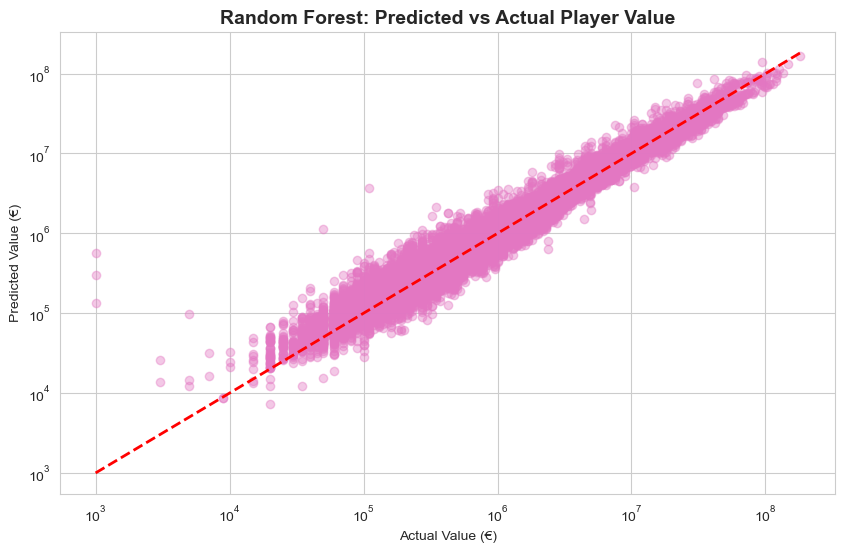

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color='#e377c2')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value (€)')
plt.ylabel('Predicted Value (€)')
plt.title('Random Forest: Predicted vs Actual Player Value', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.yscale('log')
plt.savefig('../visuals/predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Conclusion

- **Random Forest** significantly outperforms Linear Regression for predicting player values.
- **Overall rating** and **wage** are the strongest predictors of market value.
- Age has a non-linear effect: young high-potential players are valued more than older players with the same rating.
- Top 5 European leagues (EPL, La Liga, Bundesliga, Serie A, Ligue 1) dominate average valuations.

**Next steps:** Try XGBoost, add player-position-specific models, and build a Streamlit app for live predictions.